## 1

In [7]:
import torch
import torch.nn as nn

# 1. Create a simple RNN layer
# input_size=2 (features), hidden_size=4 (units)
rnn_layer = nn.RNN(input_size=2, hidden_size=4, batch_first=True)

# 2. Pass dummy input (batch_size=1, timesteps=3, features=2)
dummy_input = torch.randn(1, 3, 2)

# PyTorch returns (output_all_steps, final_hidden_state)
output_all, hidden_state = rnn_layer(dummy_input)

# In Keras, 'output' usually refers to the result of the last timestep
output_last = output_all[:, -1, :]

print("Output shape (last step):", output_last.shape)
print("Output (last step):\n", output_last.detach().numpy())
print("\nHidden State:\n", hidden_state.detach().numpy())

Output shape (last step): torch.Size([1, 4])
Output (last step):
 [[-0.11743233  0.8374013   0.34371403 -0.5486666 ]]

Hidden State:
 [[[-0.11743233  0.8374013   0.34371403 -0.5486666 ]]]


## 2

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# 1. Prepare data (PyTorch expects [batch, seq_len, features])
X = torch.tensor([[[7.0], [8.0], [9.0]]], dtype=torch.float32)
y = torch.tensor([[10.0]], dtype=torch.float32)

# 2. Define the Model Class
class SimpleRNNModel(nn.Module):
    def __init__(self):
        super(SimpleRNNModel, self).__init__()
        # input_size=1, hidden_size=16
        self.rnn = nn.RNN(input_size=1, hidden_size=16, batch_first=True)
        # Fully connected layer for the output
        self.fc = nn.Linear(16, 1)

    def forward(self, x):
        # rnn returns (output_all_steps, final_hidden_state)
        _, hn = self.rnn(x) 
        # hn shape: [num_layers, batch, hidden_size] -> we take the last layer [0]
        return self.fc(hn[0])

model = SimpleRNNModel()

# 3. Setup Loss and Optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 4. Training Loop (200 Epochs)
model.train()
for epoch in range(200):
    optimizer.zero_grad()
    outputs = model(X)
    loss = criterion(outputs, y)
    loss.backward()
    optimizer.step()

# 5. Predict
model.eval()
with torch.no_grad():
    prediction = model(X)
    print(f"Input: [7, 8, 9] | Predicted Next Number: {prediction.item():.2f}")


Input: [7, 8, 9] | Predicted Next Number: 10.00


# 3

Training complete!


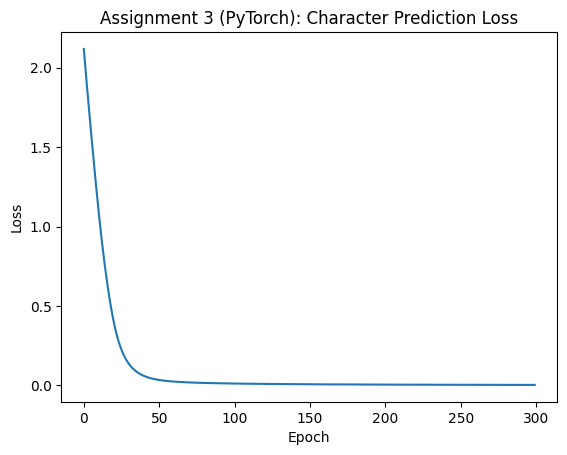

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# 1. Data preparation
text = "hello world"
chars = sorted(list(set(text)))
char_to_int = {c: i for i, c in enumerate(chars)}

# Input: "hello worl", Target: "ello world"
X_np = np.array([[char_to_int[c] for c in text[:-1]]])
y_np = np.array([[char_to_int[c] for c in text[1:]]])

X_tensor = torch.tensor(X_np, dtype=torch.long)
y_tensor = torch.tensor(y_np, dtype=torch.long)

# 2. Define Model Class
class CharRNN(nn.Module):
    def __init__(self, vocab_size):
        super(CharRNN, self).__init__()
        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=8)
        self.rnn = nn.RNN(input_size=8, hidden_size=16, batch_first=True)
        self.fc = nn.Linear(16, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.rnn(x)  # out shape: [batch, seq_len, hidden_size]
        return self.fc(out)   # out shape: [batch, seq_len, vocab_size]

model = CharRNN(len(chars))

# 3. Setup Loss and Optimizer
# CrossEntropyLoss handles the "softmax" internally
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 4. Training Loop
loss_history = []
model.train()
for epoch in range(300):
    optimizer.zero_grad()
    outputs = model(X_tensor)
    
    # Reshape for CrossEntropyLoss: (Batch, Classes, Seq_Len)
    loss = criterion(outputs.transpose(1, 2), y_tensor)
    
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

print("Training complete!")

# 5. Plot Loss Curve
plt.plot(loss_history)
plt.title('Assignment 3 (PyTorch): Character Prediction Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

# 4

Epoch [10/50], Loss: 0.0001
Epoch [20/50], Loss: 0.0001
Epoch [30/50], Loss: 0.0001
Epoch [40/50], Loss: 0.0001
Epoch [50/50], Loss: 0.0001
Epoch [60/50], Loss: 0.0001
Epoch [70/50], Loss: 0.0001
Epoch [80/50], Loss: 0.0001
Epoch [90/50], Loss: 0.0001
Epoch [100/50], Loss: 0.0001


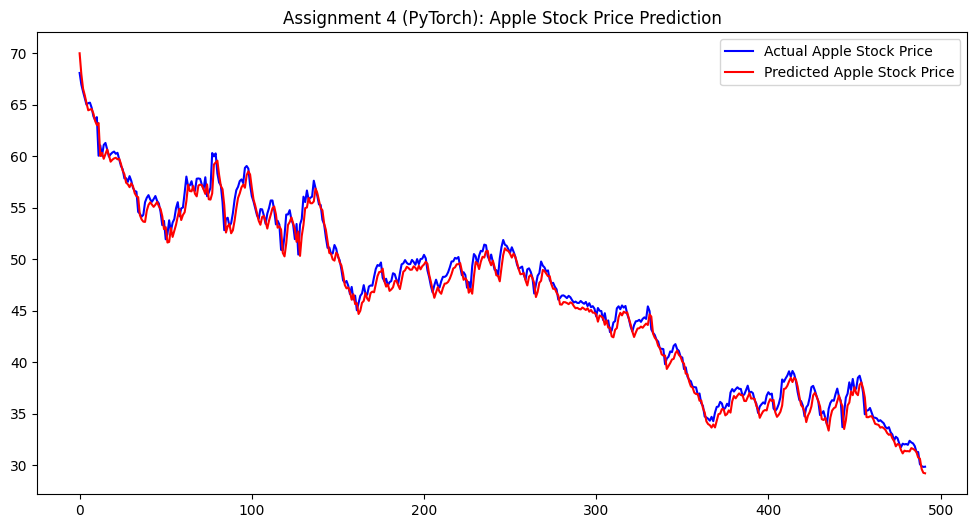

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# 1. Load and Clean Data
df = pd.read_csv('/kaggle/input/datasets/tarunpaparaju/apple-aapl-historical-stock-data/HistoricalQuotes.csv')
df[' Close/Last'] = df[' Close/Last'].str.replace('$', '').str.replace(' ', '').astype(float)
data = df[' Close/Last'].values.reshape(-1, 1)

# 2. Normalize
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# 3. Create windowed data (60 days)
window = 60
X_list, y_list = [], []
for i in range(window, len(scaled_data)):
    X_list.append(scaled_data[i-window:i, 0])
    y_list.append(scaled_data[i, 0])

X_stock = np.array(X_list).reshape(-1, window, 1)
y_stock = np.array(y_list).reshape(-1, 1)

# 4. Split and Convert to Tensors
train_size = int(len(X_stock) * 0.8)
X_train = torch.tensor(X_stock[:train_size], dtype=torch.float32)
y_train = torch.tensor(y_stock[:train_size], dtype=torch.float32)
X_test = torch.tensor(X_stock[train_size:], dtype=torch.float32)
y_test = torch.tensor(y_stock[train_size:], dtype=torch.float32)

# Create DataLoader for batching (similar to batch_size=32 in Keras)
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)

# 5. Define Model
class StockRNN(nn.Module):
    def __init__(self):
        super(StockRNN, self).__init__()
        self.rnn = nn.RNN(input_size=1, hidden_size=50, batch_first=True)
        self.fc = nn.Linear(50, 1)

    def forward(self, x):
        _, hn = self.rnn(x) # hn: [1, batch, 50]
        return self.fc(hn.squeeze(0))

model = StockRNN()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 6. Training Loop (50 Epochs)
model.train()
for epoch in range(100):
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/100], Loss: {epoch_loss/len(train_loader):.4f}")

# 7. Evaluation and Plotting
model.eval()
with torch.no_grad():
    predictions = model(X_test).numpy()
    predictions = scaler.inverse_transform(predictions)
    actual = scaler.inverse_transform(y_test.numpy())

plt.figure(figsize=(12, 6))
plt.plot(actual, color='blue', label='Actual Apple Stock Price')
plt.plot(predictions, color='red', label='Predicted Apple Stock Price')
plt.title('Assignment 4 (PyTorch): Apple Stock Price Prediction')
plt.legend()
plt.show()